In [1]:
# Install packages in the notebook environment
!pip install torch torchvision
!pip install Pillow
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
!pip install scikit-learn matplotlib

  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 MB 28.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 27.5 MB/s eta 0:00:00a 0:00:01
Using cached filelock-3.18.0-py3-none-any.whl (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 6.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 19.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)

[notice] A new release of pip is available: 25.0 -> 

In [16]:
# Add user site-packages path to Python path
import sys
import os

# Add the specific path where your packages are installed
user_packages_path = os.path.expanduser('~/.local/lib/python3.12/site-packages')
if os.path.exists(user_packages_path) and user_packages_path not in sys.path:
    sys.path.insert(0, user_packages_path)
    print(f"Added {user_packages_path} to Python path")
else:
    print(f"Path {user_packages_path} does not exist or is already in Python path")

# Print the Python path to verify
print("\nPython path:")
for p in sys.path:
    print(f"  {p}")

Added /jet/home/btuchi/.local/lib/python3.12/site-packages to Python path

Python path:
  /jet/home/btuchi/.local/lib/python3.12/site-packages
  /jet/home/btuchi
  /opt/packages/anaconda3-2024.10-1/lib/python312.zip
  /opt/packages/anaconda3-2024.10-1/lib/python3.12
  /opt/packages/anaconda3-2024.10-1/lib/python3.12/lib-dynload
  
  /opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages
  /opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/setuptools/_vendor


In [12]:
import torch
from PIL import Image
import clip
import os
import numpy as np
from tqdm import tqdm
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [3]:
def extract_clip_features(image_folder, output_file='clip_features.npz'):
    """
    Extract CLIP features from all images in a folder and save them.
    
    Args:
        image_folder: Path to folder containing images
        output_file: Path to save extracted features
    """
    # Load CLIP model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, preprocess = clip.load("ViT-B/32", device=device)
    
    print(f"CLIP model loaded on {device}")
    
    # Get list of images
    image_files = [f for f in os.listdir(image_folder) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    # Create dictionary to store features
    features_dict = {}
    
    # Process each image
    for filename in tqdm(image_files, desc="Extracting features"):
        try:
            # Load and preprocess image
            image_path = os.path.join(image_folder, filename)
            image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
            
            # Extract features
            with torch.no_grad():
                image_features = model.encode_image(image)
                
            # Normalize features
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            
            # Store features
            features_dict[filename] = image_features.cpu().numpy().flatten()
        
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    
    # Save features
    np.savez(output_file, **features_dict)
    print(f"Saved features for {len(features_dict)} images to {output_file}")
    
    return features_dict

In [4]:
def create_feature_lookup(features_npz):
    """
    Create an efficient lookup structure for features
    
    Args:
        features_npz: Path to .npz file with saved features
    
    Returns:
        feature_matrix: numpy array with all features (n_images x feature_dim)
        filename_list: list of corresponding filenames
    """
    # Load features
    data = np.load(features_npz)
    
    # Get filenames and features
    filenames = list(data.files)
    feature_matrix = np.vstack([data[filename] for filename in filenames])
    
    return feature_matrix, filenames

In [5]:
# These will be useful when I implement the diversity reward functions:

def get_features_for_images(image_list, features_dict):
    """Get feature matrix for a list of images"""
    return np.vstack([features_dict[img] for img in image_list if img in features_dict])

def extract_features_for_new_images(image_paths):
    """Extract features for new generated images"""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, preprocess = clip.load("ViT-B/32", device=device)
    
    features = []
    
    for path in image_paths:
        # Load and preprocess image
        image = preprocess(Image.open(path)).unsqueeze(0).to(device)
        
        # Extract features
        with torch.no_grad():
            image_features = model.encode_image(image)
            
        # Normalize features
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        features.append(image_features.cpu().numpy().flatten())
    
    return np.vstack(features)

In [9]:
def visualize_feature_space_with_thumbnails(feature_matrix, filenames, image_folder, output_file=None):
    """
    Visualize the feature space with image thumbnails
    """
    # Make sure to import the right modules
    
    
    # Apply t-SNE for dimensionality reduction
    tsne = TSNE(n_components=2, random_state=42)
    projected_features = tsne.fit_transform(feature_matrix)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.scatter(projected_features[:, 0], projected_features[:, 1], alpha=0.7)
    
    # Add some image thumbnails
    n_samples = min(10, len(filenames))
    for i in range(n_samples):
        try:
            img_path = os.path.join(image_folder, filenames[i])
            if os.path.exists(img_path):
                img = plt.imread(img_path)
                imagebox = AnnotationBbox(
                    OffsetImage(img, zoom=0.1), 
                    (projected_features[i, 0], projected_features[i, 1]),
                    frameon=True,
                    pad=0.2
                )
                ax.add_artist(imagebox)
        except Exception as e:
            print(f"Could not add thumbnail for {filenames[i]}: {e}")
            
    plt.title('t-SNE Visualization of CLIP Feature Space')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        
    plt.show()

In [7]:
# Feature Extraction Pipeline Implementation

# 1. Extract features for reference images
reference_folder = "reference_images"
reference_features = extract_clip_features(reference_folder, 'reference_clip_features.npz')

# 2. Create efficient lookup structure
feature_matrix, filenames = create_feature_lookup('reference_clip_features.npz')
print(f"Extracted features for {len(filenames)} reference images")
print(f"Feature dimension: {feature_matrix.shape[1]}")

100%|███████████████████████████████████████| 338M/338M [00:15<00:00, 22.7MiB/s]


CLIP model loaded on cpu


Extracting features: 100%|██████████| 68/68 [00:02<00:00, 24.03it/s]

Saved features for 68 images to reference_clip_features.npz
Extracted features for 68 reference images
Feature dimension: 512


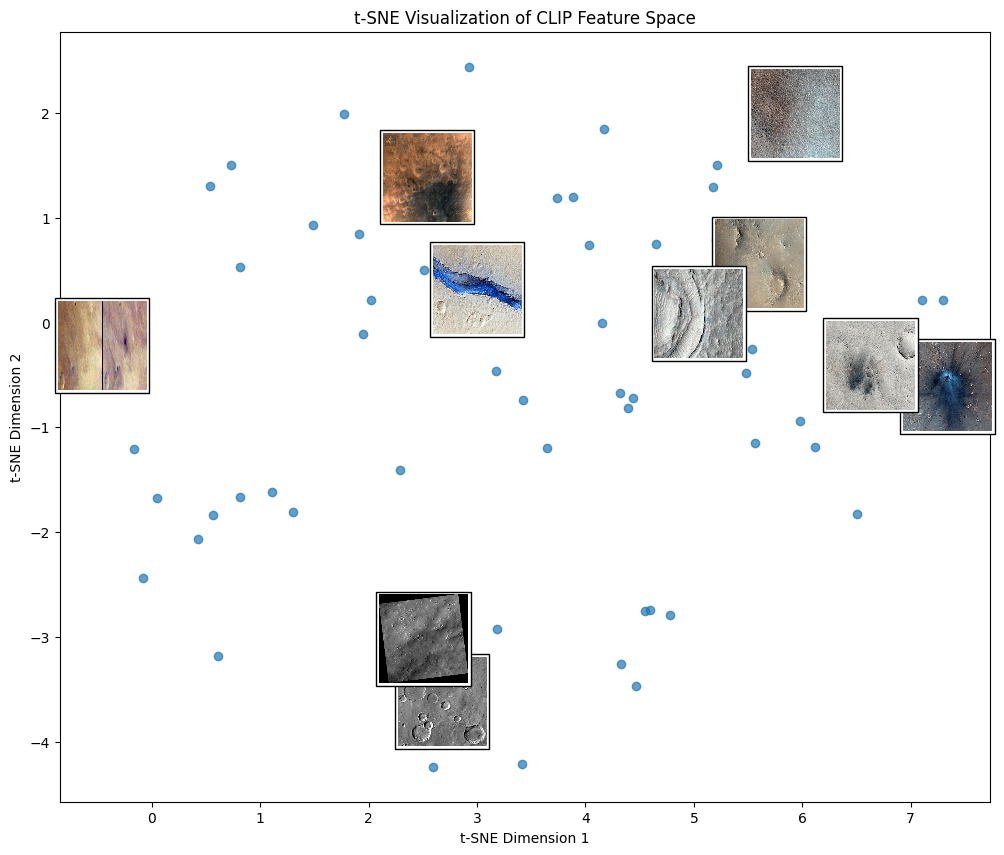

Feature extraction pipeline complete!


In [13]:
# 3. Visualize feature space to verify diversity
visualize_feature_space_with_thumbnails(feature_matrix, filenames, reference_folder, 'reference_feature_space.png')

print("Feature extraction pipeline complete!")